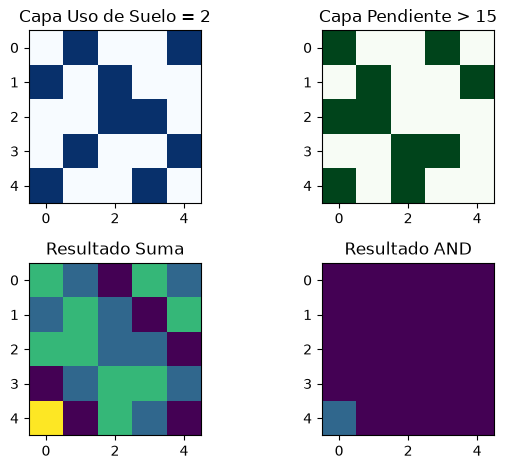

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Crear una cuadrícula de 5x5 representando píxeles
grid_size = 5

# Simulación: uso_suelo=2 en algunas celdas, pendiente>15 en otras
uso_suelo = np.array([
    [0,1,0,0,1],
    [1,0,1,0,0],
    [0,0,1,1,0],
    [0,1,0,0,1],
    [1,0,0,1,0]
])

pendiente = np.array([
    [1,0,0,1,0],
    [0,1,0,0,1],
    [1,1,0,0,0],
    [0,0,1,1,0],
    [1,0,1,0,0]
])

# Operación con suma: ("uso_suelo@1"=2) + 2*("pendiente@1">15)
resultado_suma = uso_suelo + 2*pendiente

# Operación con AND: ("uso_suelo@1"=2) AND 2*("pendiente@1">15)
resultado_and = np.where((uso_suelo==1) & (pendiente==1), 1, 0)

# Crear la figura con 3 subplots
fig, axes = plt.subplots(2, 2)

# Definir títulos
titles = ["Capa Uso de Suelo = 2", "Capa Pendiente > 15", "Resultado Suma", "Resultado AND"]

# Mostrar capas iniciales
axes[0][0].imshow(uso_suelo, cmap="Blues", vmin=0, vmax=1)
axes[0][0].set_title(titles[0])
axes[0][1].imshow(pendiente, cmap="Greens", vmin=0, vmax=1)
axes[0][1].set_title(titles[1])

# Comparar resultados lado a lado (suma arriba, AND abajo)
# combined = np.zeros((grid_size*2, grid_size))
# combined[:grid_size,:] = resultado_suma  # parte superior
# combined[grid_size:,:] = resultado_and   # parte inferior

axes[1][0].imshow(resultado_suma, cmap="viridis", vmin=0, vmax=3)
axes[1][0].set_title(titles[2])
# axes[2].axhline(grid_size-0.5, color="red", linestyle="--")
# axes[3].text(-0.7, 2, "Suma", va="center", ha="right", color="red")
# axes[3].text(-0.7, 7, "AND", va="center", ha="right", color="red")
axes[1][1].imshow(resultado_and, cmap="viridis", vmin=0, vmax=3)
axes[1][1].set_title(titles[3])

# Quitar ejes
# for ax in axes:
    # ax.axis("off")

plt.tight_layout()
plt.show()


## Figuras nuevas para Texto III (Álgebra de mapas)

A partir de acá se usa el módulo compartido `graficos_raster.py` (raíz del repositorio), con la función
`plot_raster()`: dibuja un ráster como una grilla en escala de grises con el valor de cada celda escrito
encima, el mismo patrón que ya se usaba en `Ejercícios_operadores_booleanos_raster.ipynb`. Queda pensada
como building block reutilizable, tanto para nuevas figuras del Cuadernillo como para el futuro juego/quiz
en Streamlit sobre operadores lógicos.

In [2]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Sube directorios hasta encontrar la raíz del repo (marcada por `_quarto.yml`)."""
    for parent in [start, *start.parents]:
        if (parent / "_quarto.yml").exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del repositorio (_quarto.yml)")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from graficos_raster import plot_raster

IMAGENES_DIR = REPO_ROOT / "Cuadernillo de catedra" / "nuevos" / "imagenes"


### Figura: operación local de suma (reemplaza `T3_F1.png`, ahora en español)

Dos rásters de entrada de 6×6, con el ráster 1 llevando una celda NoData que se propaga al resultado. Se
resalta con un recuadro la celda superior izquierda en las tres capas, para que se pueda seguir cómo el
valor de esa celda puntual pasa de las entradas a la salida.

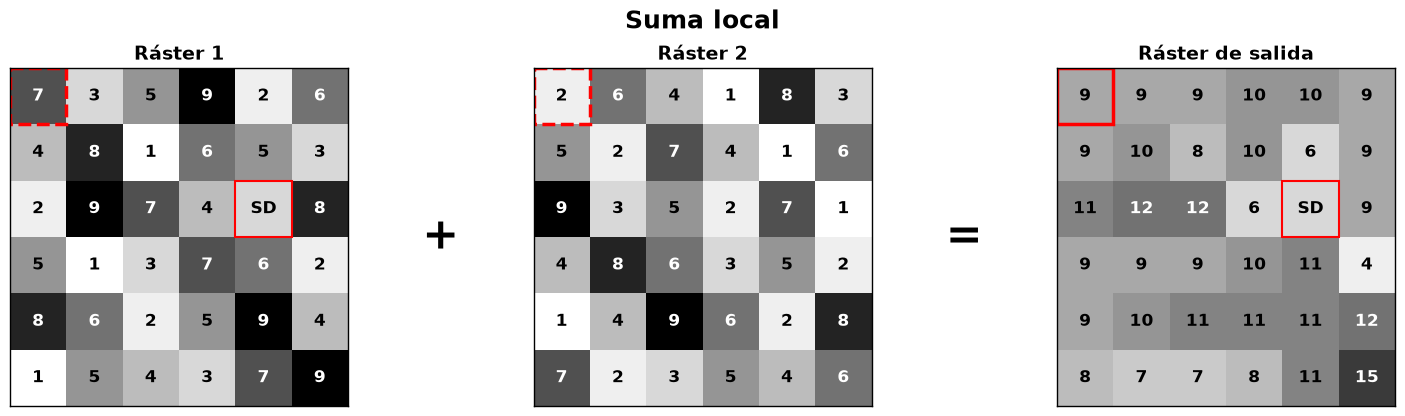

In [3]:
raster1 = np.array([
    [7., 3., 5., 9., 2., 6.],
    [4., 8., 1., 6., 5., 3.],
    [2., 9., 7., 4., 1., 8.],
    [5., 1., 3., 7., 6., 2.],
    [8., 6., 2., 5., 9., 4.],
    [1., 5., 4., 3., 7., 9.],
])
raster1[2, 4] = np.nan  # NoData en el ráster 1

raster2 = np.array([
    [2., 6., 4., 1., 8., 3.],
    [5., 2., 7., 4., 1., 6.],
    [9., 3., 5., 2., 7., 1.],
    [4., 8., 6., 3., 5., 2.],
    [1., 4., 9., 6., 2., 8.],
    [7., 2., 3., 5., 4., 6.],
])

resultado_suma_local = raster1 + raster2  # el NaN de raster1 se propaga automáticamente

fig, axes = plt.subplots(1, 5, figsize=(15, 4.2), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})
ax_r1, ax_signo_mas, ax_r2, ax_signo_igual, ax_resultado = axes

plot_raster(ax_r1, raster1, title="Ráster 1", vmin=1, vmax=9, highlight=[(0, 0)])
plot_raster(ax_r2, raster2, title="Ráster 2", vmin=1, vmax=9, highlight=[(0, 0)])
plot_raster(
    ax_resultado,
    resultado_suma_local,
    title="Ráster de salida",
    vmin=2,
    vmax=18,
    highlight=[(0, 0)],
    highlight_style="solid",
)

for ax, simbolo in [(ax_signo_mas, "+"), (ax_signo_igual, "=")]:
    ax.axis("off")
    ax.text(0.5, 0.5, simbolo, fontsize=32, fontweight="bold", ha="center", va="center")

fig.suptitle("Suma local", fontsize=18, fontweight="bold")
plt.tight_layout()

IMAGENES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(IMAGENES_DIR / "T3_F1.png", dpi=200, bbox_inches="tight")
plt.show()


### Figura: Sin Dato vs. cero (nueva, para `T3_F2.png`)

Ilustra la distinción conceptual del apartado "Sin Dato no es cero": dos filas con el mismo Ráster 2,
donde la celda superior izquierda del Ráster 1 vale 0 en la fila superior y es Sin Dato en la fila
inferior. La suma se resuelve con normalidad cuando el operando es 0 (un valor real y conocido), pero se
propaga como Sin Dato en esa misma celda cuando el operando es desconocido.

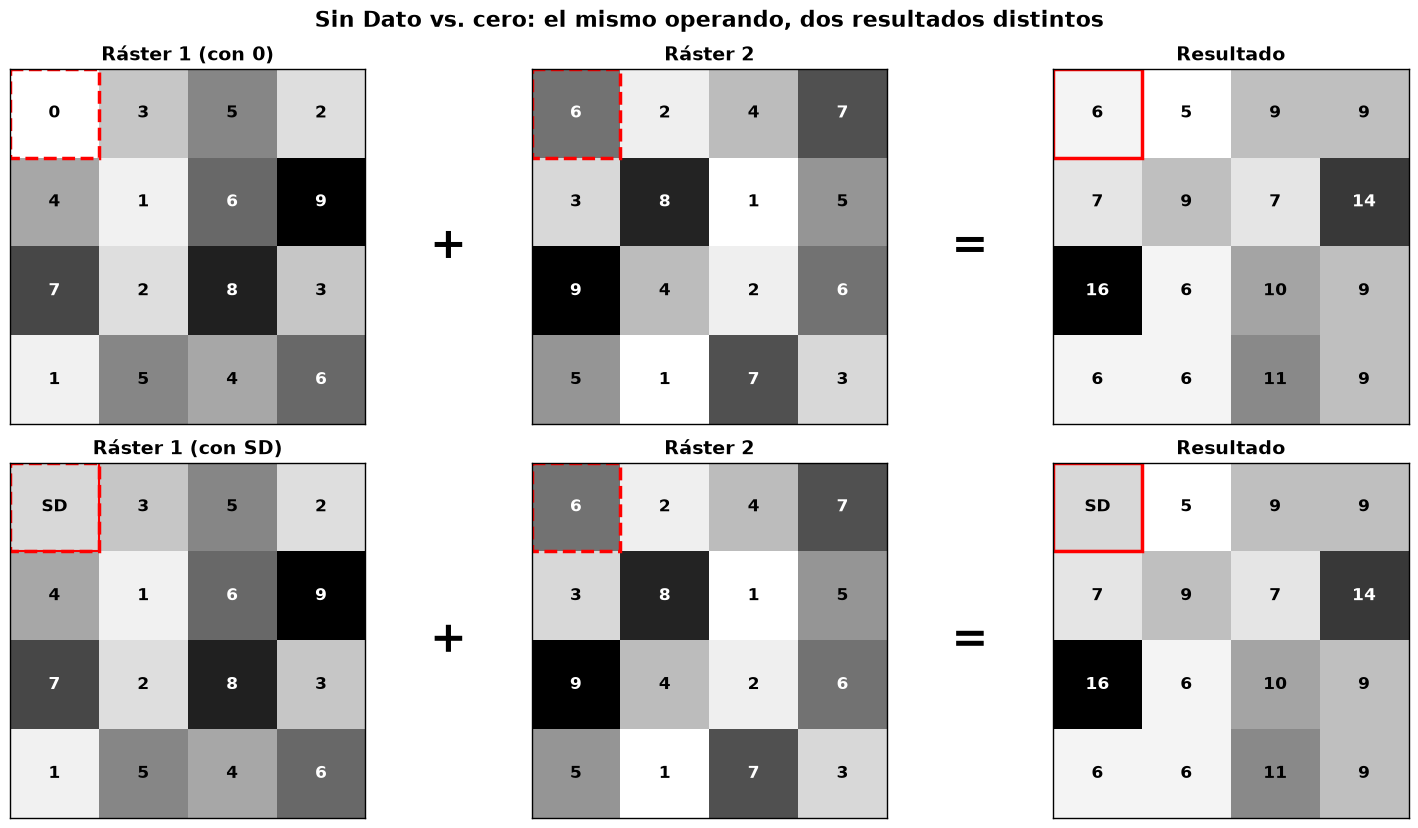

In [4]:
raster1_cero = np.array([
    [0., 3., 5., 2.],
    [4., 1., 6., 9.],
    [7., 2., 8., 3.],
    [1., 5., 4., 6.],
])
raster1_sindato = raster1_cero.copy()
raster1_sindato[0, 0] = np.nan  # la misma celda, ahora Sin Dato en vez de 0

raster2 = np.array([
    [6., 2., 4., 7.],
    [3., 8., 1., 5.],
    [9., 4., 2., 6.],
    [5., 1., 7., 3.],
])

resultado_cero = raster1_cero + raster2
resultado_sindato = raster1_sindato + raster2  # el NaN se propaga a esa única celda

fig, axes = plt.subplots(2, 5, figsize=(15, 8.4), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})

# Fila 1: la celda destacada vale 0, un dato real y conocido, y participa normalmente en la suma.
plot_raster(axes[0][0], raster1_cero, title="Ráster 1 (con 0)", vmin=0, vmax=9, highlight=[(0, 0)])
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, "+", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][2], raster2, title="Ráster 2", vmin=1, vmax=9, highlight=[(0, 0)])
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(
    axes[0][4], resultado_cero, title="Resultado", vmin=5, vmax=16, highlight=[(0, 0)], highlight_style="solid"
)

# Fila 2: la misma celda es Sin Dato, y "contamina" el resultado de la suma en esa posición.
plot_raster(axes[1][0], raster1_sindato, title="Ráster 1 (con SD)", vmin=0, vmax=9, highlight=[(0, 0)])
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "+", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][2], raster2, title="Ráster 2", vmin=1, vmax=9, highlight=[(0, 0)])
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(
    axes[1][4], resultado_sindato, title="Resultado", vmin=5, vmax=16, highlight=[(0, 0)], highlight_style="solid"
)

fig.suptitle("Sin Dato vs. cero: el mismo operando, dos resultados distintos", fontsize=16, fontweight="bold")
plt.tight_layout()

IMAGENES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(IMAGENES_DIR / "T3_F2.png", dpi=200, bbox_inches="tight")
plt.show()


### Figura: jerarquización y ponderación (nueva, para `T3_F4.png`)

Reproduce el ejemplo del apartado "Jerarquización y ponderación" de Texto III: la fila superior de cada
grilla combina pendiente = 0/1/2 con uso de suelo = 4/3/2, tres combinaciones distintas que la suma simple
mezcla en un mismo valor (4). Multiplicar la pendiente por 10 antes de sumar (`pendiente*10 + uso_suelo`)
preserva la trazabilidad y las tres celdas quedan con valores distintos.

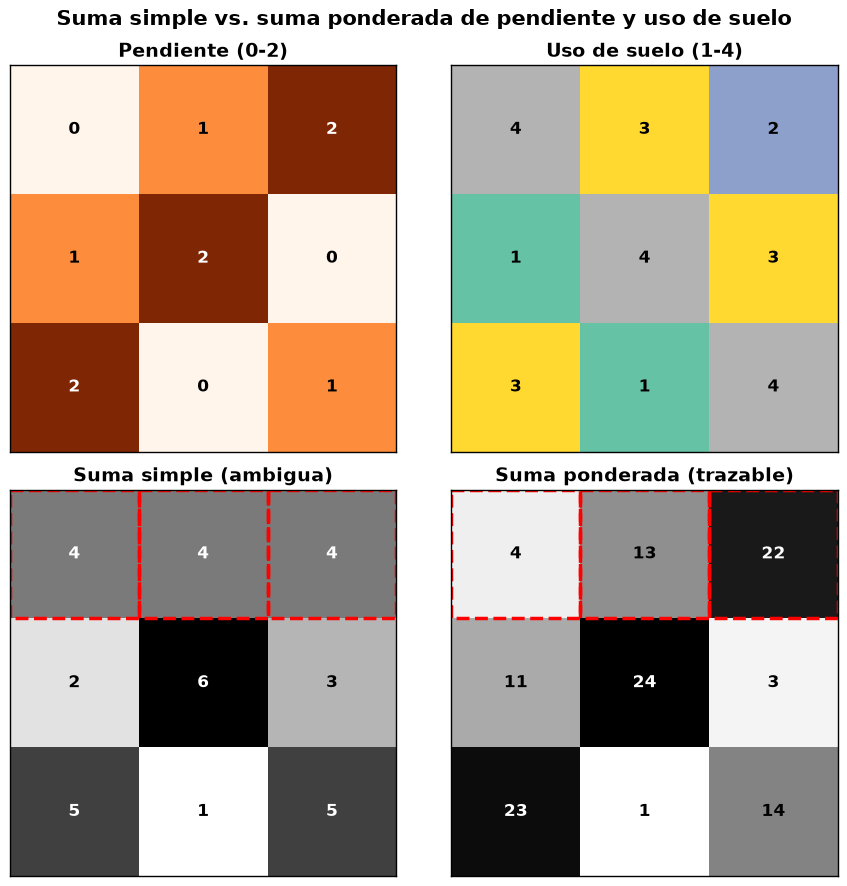

In [5]:
pendiente = np.array([
    [0, 1, 2],
    [1, 2, 0],
    [2, 0, 1],
])
uso_suelo = np.array([
    [4, 3, 2],
    [1, 4, 3],
    [3, 1, 4],
])

suma_simple = pendiente + uso_suelo
suma_ponderada = pendiente * 10 + uso_suelo

celdas_ambiguas = [(0, 0), (0, 1), (0, 2)]  # las tres combinaciones que el texto señala como ambiguas

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

# Pendiente es categórica pero ordinal (bajo/medio/alto): un cmap secuencial conserva esa noción de orden.
plot_raster(axes[0][0], pendiente, title="Pendiente (0-2)", cmap="Oranges", vmin=0, vmax=2, categorical=True)
# Uso de suelo es categórica nominal (los códigos de clase no tienen un orden real entre sí): un cmap
# cualitativo evita sugerir una gradación que no existe.
plot_raster(axes[0][1], uso_suelo, title="Uso de suelo (1-4)", cmap="Set2", vmin=1, vmax=4, categorical=True)
plot_raster(
    axes[1][0],
    suma_simple,
    title="Suma simple (ambigua)",
    cmap="Greys",
    vmin=suma_simple.min(),
    vmax=suma_simple.max(),
    highlight=celdas_ambiguas,
)
plot_raster(
    axes[1][1],
    suma_ponderada,
    title="Suma ponderada (trazable)",
    cmap="Greys",
    vmin=suma_ponderada.min(),
    vmax=suma_ponderada.max(),
    highlight=celdas_ambiguas,
)

fig.suptitle("Suma simple vs. suma ponderada de pendiente y uso de suelo", fontsize=15, fontweight="bold")
plt.tight_layout()

IMAGENES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(IMAGENES_DIR / "T3_F4.png", dpi=200, bbox_inches="tight")
plt.show()


### Figura: multiplicación por constante y división entre capas (nueva, para `T3_F3.png`)

Ilustra los otros dos operadores mencionados en "La sintaxis de la Calculadora Ráster en QGIS" (la suma ya
tiene su propia figura): multiplicar una capa por una constante, y dividir una capa por otra celda a
celda (con resultado decimal, a diferencia de las figuras anteriores).

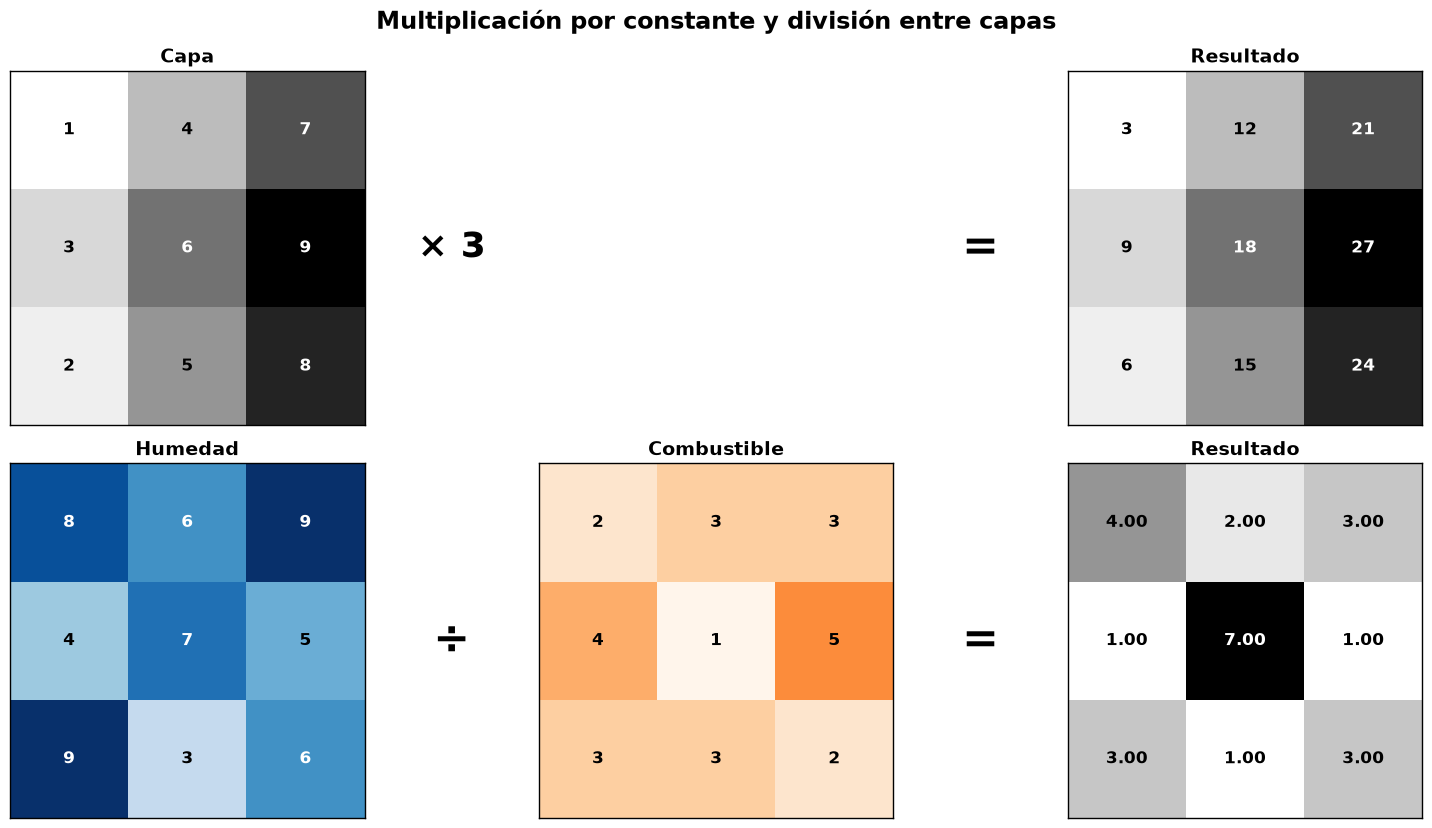

In [6]:
capa = np.array([
    [1., 4., 7.],
    [3., 6., 9.],
    [2., 5., 8.],
])
constante = 3
resultado_mult = capa * constante

capa_humedad = np.array([
    [8., 6., 9.],
    [4., 7., 5.],
    [9., 3., 6.],
])
capa_combustible = np.array([
    [2., 3., 3.],
    [4., 1., 5.],
    [3., 3., 2.],
])
resultado_division = capa_humedad / capa_combustible

fig, axes = plt.subplots(2, 5, figsize=(15, 8.4), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})

# Fila 1: multiplicación por constante
plot_raster(axes[0][0], capa, title="Capa", vmin=1, vmax=9)
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, f"× {constante}", fontsize=26, fontweight="bold", ha="center", va="center")
axes[0][2].axis("off")  # sin segunda capa: la constante ya se muestra en el panel anterior
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][4], resultado_mult, title="Resultado", vmin=resultado_mult.min(), vmax=resultado_mult.max())

# Fila 2: división entre capas
plot_raster(axes[1][0], capa_humedad, title="Humedad", cmap="Blues", vmin=1, vmax=9)
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "÷", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][2], capa_combustible, title="Combustible", cmap="Oranges", vmin=1, vmax=9)
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=32, fontweight="bold", ha="center", va="center")
plot_raster(
    axes[1][4],
    resultado_division,
    title="Resultado",
    valfmt="{:.2f}",
    vmin=resultado_division.min(),
    vmax=resultado_division.max(),
)

fig.suptitle("Multiplicación por constante y división entre capas", fontsize=17, fontweight="bold")
plt.tight_layout()

IMAGENES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(IMAGENES_DIR / "T3_F3.png", dpi=200, bbox_inches="tight")
plt.show()


### Figura: booleano (AND/OR) vs. combinación lineal ponderada (nueva, para Texto IV — `T4_F2.png`)

In [ ]:
factor_a_bool = np.array([
    [1, 0, 1],
    [1, 1, 0],
    [0, 1, 1],
])
factor_b_bool = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
])

resultado_and = factor_a_bool * factor_b_bool  # AND estricto: multiplicación
resultado_or = np.maximum(factor_a_bool, factor_b_bool)  # OR permisivo: máximo

factor_a_cont = np.array([
    [8., 3., 9.],
    [7., 6., 2.],
    [4., 9., 7.],
])
factor_b_cont = np.array([
    [6., 7., 2.],
    [3., 8., 9.],
    [9., 2., 8.],
])

peso_a, peso_b = 0.7, 0.3
resultado_wlc = peso_a * factor_a_cont + peso_b * factor_b_cont

fig, axes = plt.subplots(3, 5, figsize=(15, 12.6), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})

# Fila 1: booleano AND (multiplicación), rígido: alcanza con un 0 para que el resultado sea 0.
plot_raster(axes[0][0], factor_a_bool, title="Factor A (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, "AND\n(×)", fontsize=18, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][2], factor_b_bool, title="Factor B (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][4], resultado_and, title="AND (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])

# Fila 2: booleano OR (máximo), más permisivo: alcanza con un 1 para que el resultado sea 1.
plot_raster(axes[1][0], factor_a_bool, title="Factor A (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "OR\n(máx)", fontsize=18, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][2], factor_b_bool, title="Factor B (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][4], resultado_or, title="OR (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens", highlight=[(0, 1)])

# Fila 3: combinación lineal ponderada (WLC) sobre los mismos factores, ahora en escala continua 0-10:
# en la celda destacada, un valor bajo en A (3) se compensa parcialmente con un valor alto en B (7).
plot_raster(axes[2][0], factor_a_cont, title="Factor A (0-10)", vmin=0, vmax=10, cmap="Greens", highlight=[(0, 1)])
axes[2][1].axis("off")
axes[2][1].text(0.5, 0.5, "WLC\n(0,7·A + 0,3·B)", fontsize=13, fontweight="bold", ha="center", va="center")
plot_raster(axes[2][2], factor_b_cont, title="Factor B (0-10)", vmin=0, vmax=10, cmap="Greens", highlight=[(0, 1)])
axes[2][3].axis("off")
axes[2][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[2][4], resultado_wlc, title="Resultado WLC", vmin=0, vmax=10, cmap="Greens", highlight=[(0, 1)])

fig.suptitle("Booleano (AND/OR) vs. combinación lineal ponderada (WLC)", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGENES_DIR / "T4_F2.png", dpi=200, bbox_inches="tight")

### Figura: dos maneras de obtener una máscara booleana (nueva, para Texto IV — `T4_F1.png`)

In [ ]:
# Fila 1: booleano a partir de booleano (AND entre dos capas ya booleanas)
capa_a_bool = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
])
capa_b_bool = np.array([
    [1, 0, 1],
    [1, 1, 0],
    [0, 1, 1],
])
resultado_and = capa_a_bool * capa_b_bool

# Fila 2: booleano a partir de una capa continua (condición de umbral)
distancia_cauce = np.array([
    [50., 120., 300.],
    [80., 150., 60.],
    [200., 40., 500.],
])
resultado_condicion = (distancia_cauce >= 100).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(15, 8.4), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})

# Fila 1
plot_raster(axes[0][0], capa_a_bool, title="Capa A (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, "AND\n(×)", fontsize=18, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][2], capa_b_bool, title="Capa B (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][4], resultado_and, title="Resultado (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens")

# Fila 2
plot_raster(axes[1][0], distancia_cauce, title="Distancia al cauce (m)", vmin=0, vmax=500, cmap="Blues")
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "≥ 100 m\n(condición)", fontsize=13, fontweight="bold", ha="center", va="center")
axes[1][2].axis("off")  # sin segunda capa: la condición ya se aplica sobre la capa continua
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][4], resultado_condicion, title="Resultado (booleano)", vmin=0, vmax=1, categorical=True, cmap="Greens")

fig.suptitle("Dos maneras de obtener una máscara booleana", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGENES_DIR / "T4_F1.png", dpi=200, bbox_inches="tight")

### Figura: pendiente en grados a porcentaje (nueva, para Texto V — `T5_F1.png`)

In [ ]:
pendiente_grados = np.array([
    [5., 15., 30.],
    [10., 25., 45.],
    [2., 35., 60.],
])
pendiente_porcentaje = np.tan(np.radians(pendiente_grados)) * 100

fig, axes = plt.subplots(1, 5, figsize=(15, 4.2), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})
plot_raster(axes[0], pendiente_grados, title="Pendiente (grados)", vmin=0, vmax=60, cmap="Oranges", valfmt="{:g}")
axes[1].axis("off")
axes[1].text(0.5, 0.5, "tan(rad)\n× 100", fontsize=15, fontweight="bold", ha="center", va="center")
axes[2].axis("off")
axes[3].axis("off")
axes[3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[4], pendiente_porcentaje, title="Pendiente (%)", vmin=0, vmax=173, cmap="Oranges", valfmt="{:.1f}")
fig.suptitle("De pendiente en grados a pendiente en porcentaje", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGENES_DIR / "T5_F1.png", dpi=200, bbox_inches="tight")

### Figura: min, max y sum entre capas restrictivas (nueva, para Texto V — `T5_F2.png`)

In [ ]:
capa_a = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
])
capa_b = np.array([
    [1, 1, 0],
    [0, 0, 0],
    [1, 1, 0],
])
capa_c = np.array([
    [1, 1, 1],
    [0, 0, 1],
    [0, 1, 0],
])
resultado_min = np.minimum(np.minimum(capa_a, capa_b), capa_c)
resultado_max = np.maximum(np.maximum(capa_a, capa_b), capa_c)
resultado_sum = capa_a + capa_b + capa_c

fig, axes = plt.subplots(2, 3, figsize=(10, 8.2), constrained_layout=True)
plot_raster(axes[0][0], capa_a, title="Capa A (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[0][1], capa_b, title="Capa B (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[0][2], capa_c, title="Capa C (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[1][0], resultado_min, title="min(A, B, C)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[1][1], resultado_max, title="max(A, B, C)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[1][2], resultado_sum, title="sum(A, B, C)", vmin=0, vmax=3, cmap="Blues", categorical=True)
fig.suptitle("Tres capas restrictivas combinadas con min, max y sum", fontsize=16, fontweight="bold")
fig.get_layout_engine().set(hspace=0.15)
fig.savefig(IMAGENES_DIR / "T5_F2.png", dpi=200)

### Figura: máscara restrictiva con multiplicación vs. if() (nueva, para Texto V — `T5_F3.png`)

In [ ]:
pendiente = np.array([
    [5., 12., 20.],
    [8., 15., 3.],
    [25., 9., 11.],
])
mascara = (pendiente >= 10).astype(int)
resultado_mult = mascara * pendiente
resultado_if = np.where(pendiente >= 10, pendiente, 0)  # idéntico a resultado_mult

fig, axes = plt.subplots(3, 5, figsize=(15, 12.6), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})

# Fila 1: condición -> máscara booleana
plot_raster(axes[0][0], pendiente, title="Pendiente (grados)", vmin=0, vmax=25, cmap="Oranges")
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, "≥ 10°\n(condición)", fontsize=13, fontweight="bold", ha="center", va="center")
axes[0][2].axis("off")
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[0][4], mascara, title="Máscara restrictiva", vmin=0, vmax=1, categorical=True, cmap="Greens")

# Fila 2: máscara × pendiente original (versión con multiplicación)
plot_raster(axes[1][0], mascara, title="Máscara restrictiva", vmin=0, vmax=1, categorical=True, cmap="Greens")
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "× pendiente", fontsize=14, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][2], pendiente, title="Pendiente (grados)", vmin=0, vmax=25, cmap="Oranges")
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[1][4], resultado_mult, title="Resultado (×)", vmin=0, vmax=25, cmap="Oranges")

# Fila 3: if(pendiente >= 10, pendiente, 0) -- mismo resultado que la fila 2
plot_raster(axes[2][0], pendiente, title="Pendiente (grados)", vmin=0, vmax=25, cmap="Oranges")
axes[2][1].axis("off")
axes[2][1].text(0.5, 0.5, "if(≥ 10°,\npend., 0)", fontsize=12, fontweight="bold", ha="center", va="center")
axes[2][2].axis("off")
axes[2][3].axis("off")
axes[2][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")
plot_raster(axes[2][4], resultado_if, title="Resultado (if)", vmin=0, vmax=25, cmap="Oranges")

fig.suptitle("Máscara restrictiva de pendiente: multiplicación vs. if() explícito", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGENES_DIR / "T5_F3.png", dpi=200, bbox_inches="tight")

### Figura: comparadores compuestos, rango de pendiente con AND (nueva, para Texto V — `T5_F4.png`)

In [ ]:
pendiente = np.array([
    [5., 12., 20.],
    [8., 15., 3.],
    [25., 9., 11.],
])
mascara_ge5 = (pendiente >= 5).astype(int)
mascara_le15 = (pendiente <= 15).astype(int)
resultado_and = (mascara_ge5 & mascara_le15).astype(int)

fig, axes = plt.subplots(1, 5, figsize=(15, 4.2), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]})
ax_ge5, ax_and, ax_le15, ax_igual, ax_resultado = axes

plot_raster(ax_ge5, mascara_ge5, title="Máscara (pendiente >= 5°)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(ax_le15, mascara_le15, title="Máscara (pendiente <= 15°)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(ax_resultado, resultado_and, title="Resultado (rango 5°-15°)", vmin=0, vmax=1, categorical=True, cmap="Greens")

for ax, simbolo in [(ax_and, "AND"), (ax_igual, "=")]:
    ax.axis("off")
    ax.text(0.5, 0.5, simbolo, fontsize=22, fontweight="bold", ha="center", va="center")

fig.suptitle("Rango de pendiente entre 5° y 15° combinando dos comparadores con AND", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGENES_DIR / "T5_F4.png", dpi=200, bbox_inches="tight")


### Figura: AND y OR como intersección y unión (nueva, para Texto V — `T5_F5.png`)

In [ ]:
capa_a = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 0],
])
capa_b = np.array([
    [1, 1, 0],
    [0, 0, 0],
    [1, 1, 0],
])
resultado_and = (capa_a & capa_b).astype(int)
resultado_or = (capa_a | capa_b).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(15, 8.4), gridspec_kw={"width_ratios": [6, 1, 6, 1, 6]}, constrained_layout=True)

plot_raster(axes[0][0], capa_a, title="Capa A (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[0][2], capa_b, title="Capa B (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[0][4], resultado_and, title="Resultado AND", vmin=0, vmax=1, categorical=True, cmap="Greens")
axes[0][1].axis("off")
axes[0][1].text(0.5, 0.5, "AND\n(∩)", fontsize=16, fontweight="bold", ha="center", va="center")
axes[0][3].axis("off")
axes[0][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")

plot_raster(axes[1][0], capa_a, title="Capa A (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[1][2], capa_b, title="Capa B (booleana)", vmin=0, vmax=1, categorical=True, cmap="Greens")
plot_raster(axes[1][4], resultado_or, title="Resultado OR", vmin=0, vmax=1, categorical=True, cmap="Greens")
axes[1][1].axis("off")
axes[1][1].text(0.5, 0.5, "OR\n(∪)", fontsize=16, fontweight="bold", ha="center", va="center")
axes[1][3].axis("off")
axes[1][3].text(0.5, 0.5, "=", fontsize=22, fontweight="bold", ha="center", va="center")

fig.suptitle("AND como intersección y OR como unión entre dos capas booleanas", fontsize=16, fontweight="bold")
fig.get_layout_engine().set(hspace=0.15)
fig.savefig(IMAGENES_DIR / "T5_F5.png", dpi=200)


## Figuras para el cuestionario de Texto III

A diferencia de las anteriores, estas figuras no se embeben en el Cuadernillo: se usan como consigna de
preguntas de opción múltiple en `Cuestionarios/nuevos/Texto III – Álgebra de mapas.gift`, donde el
alumnado tiene que identificar qué operación se aplicó a partir de los valores mostrados. Por eso los
títulos de los paneles son genéricos ("Capa A", "Resultado A", etc.), sin nombrar la operación, y los
valores de ejemplo son distintos a los de las figuras del Cuadernillo (para que no alcance con memorizar
la figura ya vista). Se guardan aparte, en `Cuestionarios/nuevos/imagenes/`.

In [7]:
CUESTIONARIOS_IMAGENES_DIR = REPO_ROOT / "Cuestionarios" / "nuevos" / "imagenes"
CUESTIONARIOS_IMAGENES_DIR.mkdir(parents=True, exist_ok=True)


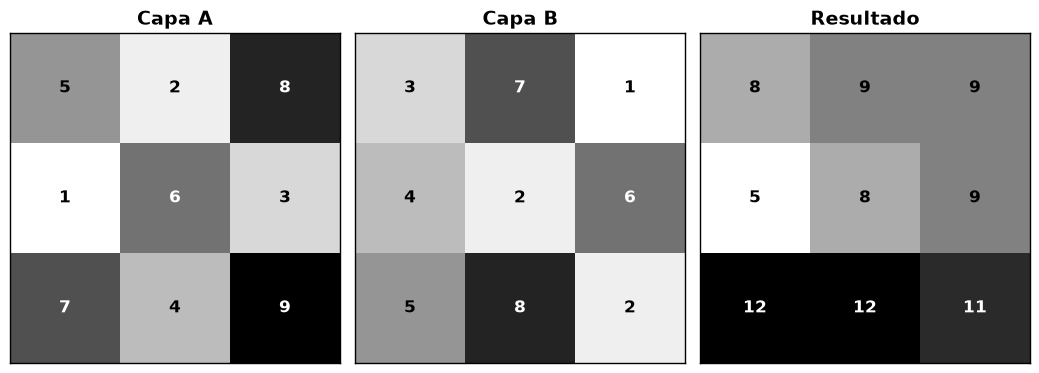

In [8]:
# Pregunta 1 (Categoría 1): dos capas de entrada y su resultado, sin revelar la operación.
capa_a = np.array([
    [5., 2., 8.],
    [1., 6., 3.],
    [7., 4., 9.],
])
capa_b = np.array([
    [3., 7., 1.],
    [4., 2., 6.],
    [5., 8., 2.],
])
resultado_misterio_1 = capa_a + capa_b  # suma local

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4))
plot_raster(axes[0], capa_a, title="Capa A", vmin=1, vmax=9)
plot_raster(axes[1], capa_b, title="Capa B", vmin=1, vmax=9)
plot_raster(axes[2], resultado_misterio_1, title="Resultado", vmin=resultado_misterio_1.min(), vmax=resultado_misterio_1.max())
plt.tight_layout()

fig.savefig(CUESTIONARIOS_IMAGENES_DIR / "T3_operacion_misteriosa_1.png", dpi=200, bbox_inches="tight")
plt.show()


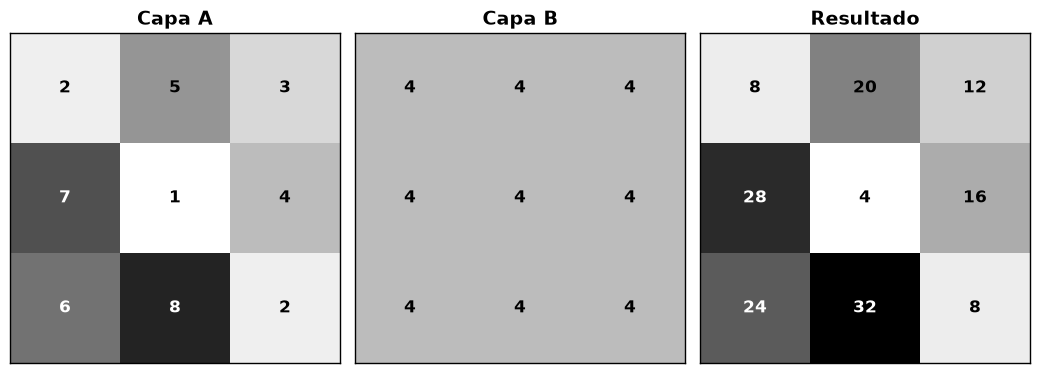

In [9]:
# Pregunta 2 (Categoría 3): la Capa B es uniforme (mismo valor en todas las celdas), representando
# visualmente una constante, para que se identifique la multiplicación por una constante sin que el
# panel diga "constante" en ningún lado.
capa_a2 = np.array([
    [2., 5., 3.],
    [7., 1., 4.],
    [6., 8., 2.],
])
capa_b2 = np.full((3, 3), 4.)
resultado_misterio_2 = capa_a2 * capa_b2

fig, axes = plt.subplots(1, 3, figsize=(10.5, 4))
plot_raster(axes[0], capa_a2, title="Capa A", vmin=1, vmax=9)
plot_raster(axes[1], capa_b2, title="Capa B", vmin=1, vmax=9)
plot_raster(axes[2], resultado_misterio_2, title="Resultado", vmin=resultado_misterio_2.min(), vmax=resultado_misterio_2.max())
plt.tight_layout()

fig.savefig(CUESTIONARIOS_IMAGENES_DIR / "T3_operacion_misteriosa_2.png", dpi=200, bbox_inches="tight")
plt.show()


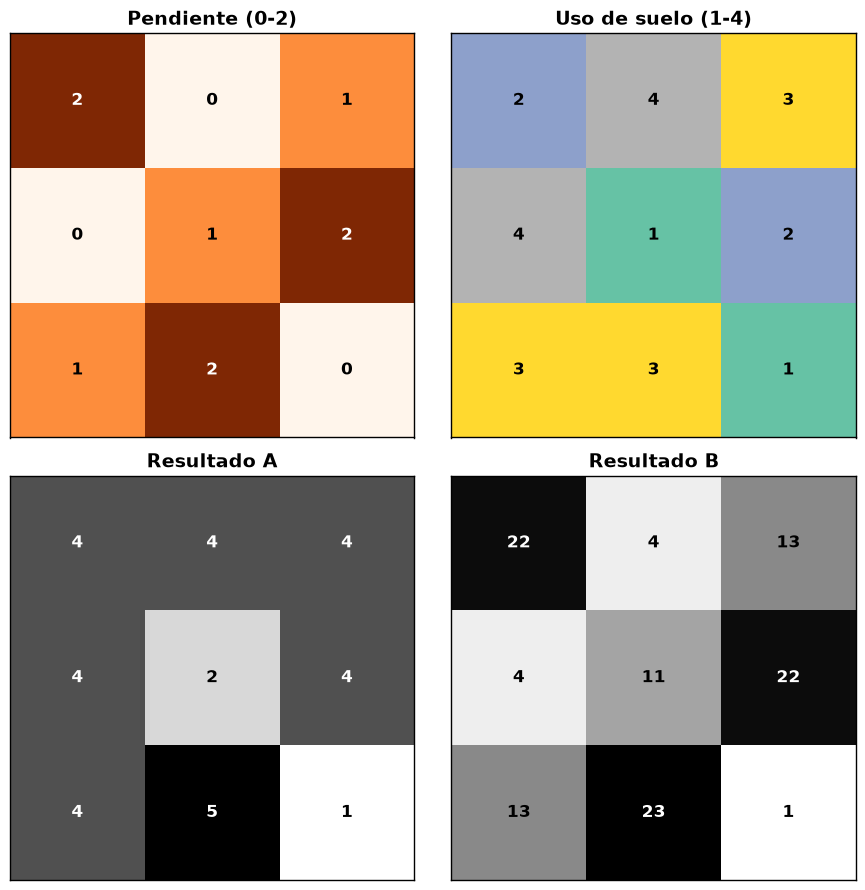

In [10]:
# Pregunta 3 (Categoría 4): dos resultados posibles de combinar pendiente y uso de suelo, etiquetados de
# forma neutra ("Resultado A"/"Resultado B") para que el alumnado identifique cuál preserva la
# trazabilidad de cada componente, sin que el título se lo diga.
pendiente_3 = np.array([
    [2, 0, 1],
    [0, 1, 2],
    [1, 2, 0],
])
uso_suelo_3 = np.array([
    [2, 4, 3],
    [4, 1, 2],
    [3, 3, 1],
])

resultado_a_3 = pendiente_3 + uso_suelo_3  # suma simple, ambigua
resultado_b_3 = pendiente_3 * 10 + uso_suelo_3  # suma ponderada, trazable

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
plot_raster(axes[0][0], pendiente_3, title="Pendiente (0-2)", cmap="Oranges", vmin=0, vmax=2, categorical=True)
plot_raster(axes[0][1], uso_suelo_3, title="Uso de suelo (1-4)", cmap="Set2", vmin=1, vmax=4, categorical=True)
plot_raster(axes[1][0], resultado_a_3, title="Resultado A", cmap="Greys", vmin=resultado_a_3.min(), vmax=resultado_a_3.max())
plot_raster(axes[1][1], resultado_b_3, title="Resultado B", cmap="Greys", vmin=resultado_b_3.min(), vmax=resultado_b_3.max())
plt.tight_layout()

fig.savefig(CUESTIONARIOS_IMAGENES_DIR / "T3_operacion_misteriosa_3.png", dpi=200, bbox_inches="tight")
plt.show()
